In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
import csv
import glob
import seaborn as sns
import scipy
from scipy.optimize import curve_fit

In [2]:
fields = [((-1,  1), ( 1,  1)), (( 1, -1), ( 1,  1)), (( 1 , 1), (-1,  1)), (( 1,  1), ( 1, -1)),
          ((-1, -1), (-1,  1)), (( 1, -1), (-1, -1)), ((-1,  1), (-1, -1)), ((-1, -1), ( 1, -1)),
          ((-1, -1), (-1, -1)), (( 1,  1), ( 1,  1)), (( 1, -1), (-1,  1)), ((-1,  1), ( 1, -1)),
          ((-1, -1), ( 1,  1)), ((-1,  1), (-1,  1)), (( 1, -1), ( 1, -1)), (( 1,  1), (-1, -1)),
          'single_u', 'single_d', 'Ezz', 'Ez', 'Ex', "cross_u", "cross_d", 'Epps', 'Emms', 'Ezzs']
gs = {field: {} for field in fields}

for fname in glob.glob("./gs/**/ZZ/gs_*.npy", recursive=True):
    d = np.load(fname, allow_pickle=True).item()
    param = fname.split("/")
    nn = param[3].split("_")
    hz = float(nn[1][3:])
    ggc = float(nn[2][4:])
    D = int(nn[3][2:])
    ind = (hz, ggc, D)
    for field in fields:
        if field in d:
            gs[field][ind] = d[field]

fgs = {}
pgs = {}
hzs = [0] + [2 ** x for x in [-4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5, 0, 0.5, 1]]
hzs = [float(f"{hz:0.4f}") for hz in hzs]

Dtarget = 4

for field in fields:
    fgs[field] = {}
    pgs[field] = {}
    for hz in hzs:
        hz = float(f"{hz:0.4f}")
        tmp = {k[1]: v for k, v in gs[field].items() if k[0] == hz and k[2] == Dtarget}
        tmp = dict(sorted(tmp.items()))
        xx = list(tmp.keys())
        yy = list(tmp.values())
        pgs[field][hz] = (xx, yy)
        if xx:
            if field == 'Ez':
                print(hz, max(xx))
            if field in ['Epps', 'Emms', 'Ezzs']:
                fgs[field][hz] = {}
                for i in range(20):
                    yyy = [x[i] for x in yy]
                    fgs[field][hz][i] = scipy.interpolate.UnivariateSpline(xx, yyy, s=0, k=4)
            else:
                fgs[field][hz] = scipy.interpolate.UnivariateSpline(xx, yy, s=0, k=4)


0.0 4.0
0.0625 4.0
0.0884 4.0
0.125 4.0
0.1768 4.0
0.25 4.0
0.3536 4.0
0.5 4.0
0.7071 4.0
1.0 4.0
1.4142 4.0
2.0 4.0


In [3]:
Eset = [-2]

In [4]:
four = {}
cc = {}
ee = []
ii = 0
for fname in glob.glob("./bias_dwave/**/env_*.npy", recursive=True):
    param = fname.split("/")
    hz = float(param[2][3:])
    ta = float(param[3][3:])
    bb = param[5]
    E = float(param[4][2:])
    nn = param[6].split("_")

    D = eval(nn[1][2:])
    chi = int(nn[2][4:])
    which = nn[3][7:-1]
    sf = float(nn[4][3:-4])
    sym = 'dense' if "/ZZ/" in fname else 'Z2'
    ind = (sym, which, D, chi, sf)

    if E in Eset  and 'hz=0.0000' in fname and 'ta=4.0000' in fname:
        ee.append(ind)
        d = np.load(fname, allow_pickle=True).item()
        cc[ind] = d['info'].converged
        if 'four' in d:
            four[ind] = d['four']
        else:
            ii += 1
            print(fname)


In [5]:
data = {}
for fname in glob.glob("./bias_dwave/**/data_sf=*.csv", recursive=True):
    param = fname.split("/")
    hz = float(param[2][3:])
    ta = float(param[3][3:])
    E = float(param[4][2:5])
    sym = 'dense' if "ZZ" in param[5] else 'Z2'

    fieldnames = ["D", "which", "chi", "dt", "Delta", "time", "Ezz", "Ez", "Ex"]
    dtypes =     [int, str, int, float, float, float, float, float, float]
    sf = float(param[6][8:12])
    ind = (float(hz), float(ta), float(E), float(sf))

    if E in Eset  and hz==0.0000 and ta==4.0000:
        with open(fname, 'r', newline='') as csvfile:
            csvfile.readline()
            for x in csv.DictReader(csvfile, fieldnames=fieldnames, delimiter=";"):
                x = x.copy()
                for fn, typ in zip(fieldnames, dtypes):
                    try:
                        x[fn] = typ(x[fn])
                    except:
                        x[fn] = eval(x[fn])
                x["Eng"] = (-2 * x["Ezz"] - float(hz) * x["Ez"])
                ind = (sym, x['which'], x['D'], x['chi'], sf)
                data[ind] = x


In [6]:
kk = set(ind[:4] for ind in four)

In [7]:
val = 'Ezz'
dd = {}
for ii in kk:
    dd[ii] = []

for ind, v in four.items():
    if val in v:
        dd[ind[:4]].append( (ind[4], v[val]) )

for k, v in dd.items():
    dd[k] = sorted(v)
    dd[k] = (tuple(v[0] for v in dd[k]), tuple(v[1] for v in dd[k]))

In [8]:
kkk = set(ind[:4] for ind in data)

In [9]:
val = 'Delta'
ee = {}
for ii in kkk:
    ee[ii] = []

for ind, v in data.items():
    if val in v:
        ee[ind[:4]].append( (ind[4], v[val]) )

for k, v in ee.items():
    ee[k] = sorted(v)
    ee[k] = (tuple(v[0] for v in ee[k]), tuple(v[1] for v in ee[k]))

In [10]:
aaa = {}
vvs = []
for ii in kk:
    #if ii[3] == 16: # and (ii[2] != (32, 12) and ii[2] != 8):
        ss = np.array(dd[ii][0])
        vv = np.array(dd[ii][1])
        try:
            ind = np.where(ss == 0.1)[0].item()
            ss = ss[ind:]
            vv = vv[ind:]
        except ValueError:
             pass
        if len(vv) == 91:
            vvs.append(vv)

        aaa[ii] = (ss, vv)

ref = np.median(np.stack(vvs), axis=0)

In [11]:
bbb = {}
vvs = []
for ii in kkk:
    #if ii[3] == 16: # and (ii[2] != (32, 12) and ii[2] != 8):
        ss = np.array(ee[ii][0])
        vv = np.array(ee[ii][1])
        try:
            ind = np.where(ss == 0.1)[0].item()
            ss = ss[ind:]
            vv = vv[ind:]
        except ValueError:
             pass
        if len(vv) == 91:
            vvs.append(vv)

        bbb[ii] = (ss, vv)

# ref = np.median(np.stack(vvs), axis=0)

In [12]:
for k, v in sorted(aaa.items()):
    print(k, len(v[0]))

('Z2', 'BP', (32, 12), 16) 91
('Z2', 'BP', (32, 16), 16) 91
('Z2', 'Ladder+BP', 8, 16) 91
('Z2', 'Ladder+BP', 12, 16) 91
('Z2', 'Ladder+BP', 16, 16) 91
('Z2', 'NN+', 8, 16) 91
('Z2', 'NN+', 12, 16) 91
('Z2', 'NN+', 16, 16) 91
('Z2', 'NN+BP', 8, 16) 91
('Z2', 'NN+BP', 12, 16) 91
('Z2', 'NNN+BP', 8, 16) 91
('dense', 'BP', (32, 12), 16) 91
('dense', 'BP', (32, 16), 16) 91
('dense', 'Ladder+BP', 8, 16) 91
('dense', 'Ladder+BP', 8, 32) 91
('dense', 'Ladder+BP', 12, 16) 91
('dense', 'Ladder+BP', 12, 32) 91
('dense', 'Ladder+BP', 16, 16) 91
('dense', 'NN+', 8, 16) 91
('dense', 'NN+', 12, 16) 91
('dense', 'NN+', 16, 16) 91
('dense', 'NN+BP', 8, 16) 91
('dense', 'NN+BP', 8, 32) 91
('dense', 'NN+BP', 12, 16) 91
('dense', 'NNN+BP', 8, 16) 91
('dense', 'NNN+BP', 8, 32) 91


In [13]:
from matplotlib import colormaps as cms
cm = cms['tab20']

In [14]:
ll = sorted({ii[1:3] for ii in aaa.keys()})
cm = [cms['tab10'](ii) for ii in range(20)]
cmm = dict(zip(ll, cm))

Text(0.5, 0, 's')

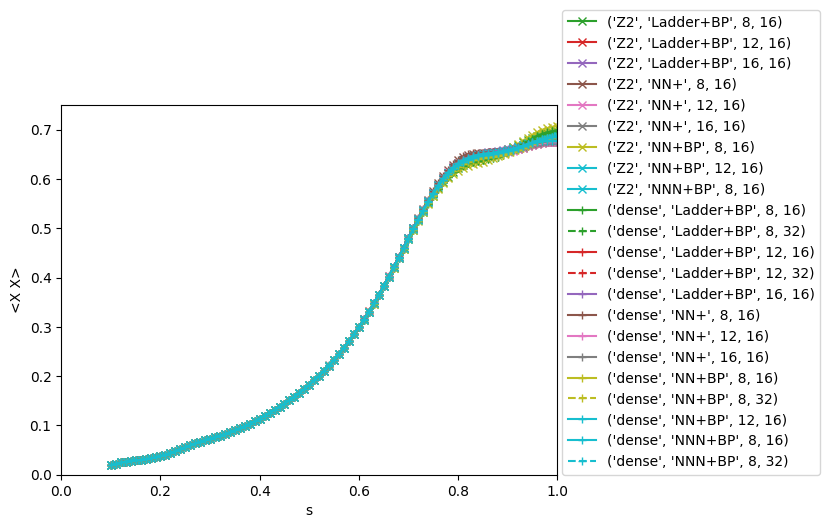

In [18]:

gc = 3.04438


lll = 0


for ii, (ss, vv) in sorted(aaa.items()):
    if ii[2] in [8, 12, 16]:
        lll += 1
        vv = vv #- ref
        sym = '-' if ii[3] == 16 else '--'
        sym = sym + ('+' if ii[0] == 'dense' else 'x')
        plt.plot(ss, vv, sym, label=f"{ii}", color=cmm[ii[1:3]])

plt.legend(loc=(1.01,0))
plt.xlim([0.0, 1])
plt.ylim([0.0, 0.75])
plt.ylabel("<X X>")
plt.xlabel("s")

Text(0.5, 0, 's')

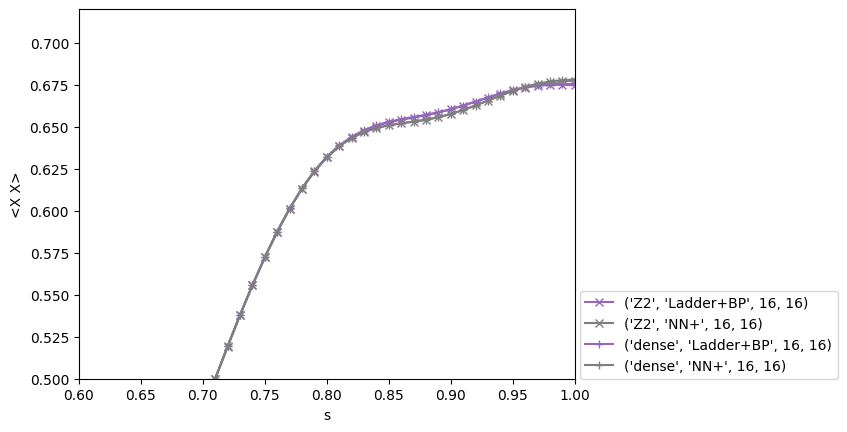

In [22]:

gc = 3.04438


lll = 0


for ii, (ss, vv) in sorted(aaa.items()):
    if ii[2] in [16]:
        lll += 1
        vv = vv #- ref
        sym = '-' if ii[3] == 16 else '--'
        sym = sym + ('+' if ii[0] == 'dense' else 'x')
        plt.plot(ss, vv, sym, label=f"{ii}", color=cmm[ii[1:3]])

plt.legend(loc=(1.01,0))
plt.xlim([0.6, 1])
plt.ylim([0.5, 0.72])
plt.ylabel("<X X>")
plt.xlabel("s")